In [16]:
import os
import sys
# block warnings from printing
import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore')

import collections
import xarray as xr
xr.set_options(keep_attrs=True)
import netCDF4 as nc
import numpy as np
np.seterr(divide='ignore', invalid='ignore')
import metpy.calc as mp
from metpy.units import units
from scipy.stats import ttest_ind, ttest_rel
from scipy.ndimage import gaussian_filter1d
from scipy.interpolate import RegularGridInterpolator
from scipy.stats import binned_statistic
from datetime import datetime
import cf_xarray
import cftime
import pyproj
from pyproj import Geod

import cartopy
cartopy.config['data_dir'] = "/discover/nobackup/projects/jh_tutorials/JH_examples/JH_datafiles/Cartopy"
cartopy.config['pre_existing_data_dir'] = "/discover/nobackup/projects/jh_tutorials/JH_examples/JH_datafiles/Cartopy"
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from shapely.geometry.polygon import LinearRing
from shapely.geometry import LineString, Point
import regionmask 

import matplotlib as mpl
from matplotlib.lines import Line2D
import matplotlib.patches as patches
import matplotlib.patheffects as pe
import matplotlib.pyplot as plt
from matplotlib.offsetbox import AnchoredText
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
from matplotlib.colors import TwoSlopeNorm
from matplotlib import cm
from matplotlib.colors import ListedColormap,LinearSegmentedColormap
import cmocean.cm as cmo
import seaborn as sns

# settings
%config InlineBackend.figure_format = 'retina'

# add path to custom functions
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path+"/py_functions")
from map_plot_tools import *
from colorbar_funcs import *
from data_funcs import *
from stats_funcs import *

dpath0='/discover/nobackup/projects/giss/baldwin_nip/dmkumar' # top level data directory
opath='/home/dmkumar/JupyterLinks/notebooks/topo_nam'

In [2]:
def match_lat_lon_names(ds):
    for lat_name in ['y', 'latitude', 'nav_lat']:
        if (lat_name in ds.coords) and ('lat' not in ds.coords):
            ds=ds.rename({lat_name: 'lat'})
        else:
            ds=ds
    for lon_name in ['x', 'longitude', 'nav_lon']:
        if (lon_name in ds.coords) and ('lon' not in ds.coords):
            ds = ds.rename({lon_name: 'lon'})
        else:
            ds=ds
    return ds

def jas_seasonal_mean(ds):
    """
    Calculate seasonal mean accounting for varying month lengths
    ** assumes no leap **
    """    
    jas = ds.sel(time=ds['time.month'].isin([7, 8, 9]))
    weights = jas['time'].dt.days_in_month
    jas_weighted_mean = (jas * weights).sum(dim='time') / weights.sum(dim='time')
    return jas_weighted_mean

def jas_yearly_mean(ds):
    """
    Calculate jas seasonal mean for each year, accounting for varying month lengths
    ** assumes no leap **
    """ 
    jas = ds.sel(time=ds['time.month'].isin([7, 8, 9]))
    weights = jas['time'].dt.days_in_month
    jas_yearly_weighted_mean = ((jas * weights).groupby('time.year').sum(dim='time') / weights.groupby('time.year').sum(dim='time'))
    return jas_yearly_weighted_mean

def rotated_box(lon0, lat0, width, height, angle_deg):
    angle = np.deg2rad(angle_deg)

    # Half sizes
    dx = width / 2
    dy = height / 2

    # Corners relative to center
    corners = np.array([
        [-dx, -dy],
        [ dx, -dy],
        [ dx,  dy],
        [-dx,  dy]
    ])

    # Rotation matrix
    R = np.array([
        [np.cos(angle), -np.sin(angle)],
        [np.sin(angle),  np.cos(angle)]
    ])

    rotated = corners @ R.T
    rotated[:, 0] += lon0
    rotated[:, 1] += lat0

    return rotated

def regional_weighted_mean(da, region_name):

    mask3d = regions.mask_3D(da)
    region_index = regions.names.index(region_name)
    masked = da.where(mask3d.sel(region=region_index))
    weights = np.cos(np.deg2rad(da.lat))
    
    return masked.weighted(weights).mean(("lat", "lon"))


In [3]:
models=['CAM-MPAS',
        'CAMS-CSM1-0',
        'CMCC-CM2',
        'CNRM-CM6-1',
        'EC-Earth3P',
        'ECMWF-IFS',
        'FGOALS-f3',
        'GFDL-CM4',
        'HadGEM3-GC31',
        'HiRAM-SIT',
        'INM-CM5',
        'IPSL-CM6A',
        'MPI-ESM1-2',
        'MRI-ESM2',
        'NICAM16']

lr_map = {
    'CAM-MPAS': ['CAM-MPAS-LR'],
    'CAMS-CSM1-0': ['CAMS-CSM1-0-LR'],
    'CMCC-CM2': ['CMCC-CM2-HR4'],
    'CNRM-CM6-1': ['CNRM-CM6-1'],
    'EC-Earth3P': [],
    'ECMWF-IFS': ['ECMWF-IFS-LR'],
    'FGOALS-f3': ['FGOALS-f3-L'],
    'GFDL-CM4': ['GFDL-CM4'],
    'HadGEM3-GC31': ['HadGEM3-GC31-LM'],
    'HiRAM-SIT': [],
    'INM-CM5': ['INM-CM5-0'],
    'IPSL-CM6A': ['IPSL-CM6A-LR'],
    'MPI-ESM1-2': ['MPI-ESM1-2-LR'],
    'MRI-ESM2': ['MRI-ESM2-0'],
    'NICAM16': [],
}

hr_map = {
    'CAM-MPAS': ['CAM-MPAS-HR'],
    'CAMS-CSM1-0': ['CAMS-CSM1-0'],
    'CMCC-CM2': ['CMCC-CM2-VHR4'],
    'CNRM-CM6-1': ['CNRM-CM6-1-HR'],
    'EC-Earth3P': ['EC-Earth3P', 'EC-Earth3P-HR'],
    'ECMWF-IFS': ['ECMWF-IFS-HR'],
    'FGOALS-f3': ['FGOALS-f3-H'],
    'GFDL-CM4': ['GFDL-CM4C192'],
    'HadGEM3-GC31': ['HadGEM3-GC31-MM', 'HadGEM3-GC31-HM'],
    'HiRAM-SIT': ['HiRAM-SIT-LR', 'HiRAM-SIT-HR'],
    'INM-CM5': ['INM-CM5-H'],
    'IPSL-CM6A': ['IPSL-CM6A-ATM-HR'],
    'MPI-ESM1-2': ['MPI-ESM1-2-HR', 'MPI-ESM1-2-XR'],
    'MRI-ESM2': ['MRI-AGCM3-2-H', 'MRI-AGCM3-2-S'],
    'NICAM16': ['NICAM16-7S', 'NICAM16-8S'],
}

In [3]:
models=['CAM-MPAS-LR',
        'CAM-MPAS-HR',
        'CAMS-CSM1-0-LR',
        'CAMS-CSM1-0',
        'CMCC-CM2-HR4',
        'CMCC-CM2-VHR4',
        'CNRM-CM6-1',
        'CNRM-CM6-1-HR',
        'EC-Earth3P',
        'EC-Earth3P-HR',
        'ECMWF-IFS-LR',
        'ECMWF-IFS-HR',
        'FGOALS-f3-L',
        'FGOALS-f3-H',
        'GFDL-CM4',
        'GFDL-CM4C192',
        'HadGEM3-GC31-LM',
        'HadGEM3-GC31-MM',
        'HadGEM3-GC31-HM',
        'HiRAM-SIT-LR',
        'HiRAM-SIT-HR',
        'INM-CM5-0',
        'INM-CM5-H',
        'IPSL-CM6A-LR',
        'IPSL-CM6A-ATM-HR',
        'MPI-ESM1-2-LR',
        'MPI-ESM1-2-HR',
        'MPI-ESM1-2-XR',
        'MRI-ESM2-0',
        'MRI-AGCM3-2-H',
        'MRI-AGCM3-2-S',
        'NICAM16-7S',
        'NICAM16-8S']

lr_map = {
    'CAM-MPAS': ['CAM-MPAS-LR'],
    'CAMS-CSM1-0': ['CAMS-CSM1-0-LR'],
    'CMCC-CM2': ['CMCC-CM2-HR4'],
    'CNRM-CM6-1': ['CNRM-CM6-1'],
    'EC-Earth3P': ['EC-Earth3P'],
    'ECMWF-IFS': ['ECMWF-IFS-LR'],
    'FGOALS-f3': ['FGOALS-f3-L'],
    'GFDL-CM4': ['GFDL-CM4'],
    'HadGEM3-GC31': ['HadGEM3-GC31-LM'],
    'HiRAM-SIT': ['HiRAM-SIT-LR'],
    'INM-CM5': ['INM-CM5-0'],
    'IPSL-CM6A': ['IPSL-CM6A-LR'],
    'MPI-ESM1-2': ['MPI-ESM1-2-LR'],
    'MRI-ESM2': ['MRI-ESM2-0'],
    'NICAM16': ['NICAM16-7S'],
}

hr_map = {
    'CAM-MPAS': ['CAM-MPAS-HR'],
    'CAMS-CSM1-0': ['CAMS-CSM1-0'],
    'CMCC-CM2': ['CMCC-CM2-VHR4'],
    'CNRM-CM6-1': ['CNRM-CM6-1-HR'],
    'EC-Earth3P': ['EC-Earth3P-HR'],
    'ECMWF-IFS': ['ECMWF-IFS-HR'],
    'FGOALS-f3': ['FGOALS-f3-H'],
    'GFDL-CM4': ['GFDL-CM4C192'],
    'HadGEM3-GC31': ['HadGEM3-GC31-MM', 'HadGEM3-GC31-HM'],
    'HiRAM-SIT': ['HiRAM-SIT-HR'],
    'INM-CM5': ['INM-CM5-H'],
    'IPSL-CM6A': ['IPSL-CM6A-ATM-HR'],
    'MPI-ESM1-2': ['MPI-ESM1-2-HR', 'MPI-ESM1-2-XR'],
    'MRI-ESM2': ['MRI-AGCM3-2-H', 'MRI-AGCM3-2-S'],
    'NICAM16': ['NICAM16-8S'],
}

In [4]:
## +++ LOAD HRMIP DATA +++ ##

# store file paths in dictionary
files = {}
varn = 'pr'
case = 'highresSST-present'

for model in models:
    for cfg in lr_map[model] + hr_map[model]:
        files[cfg] = (f"{dpath0}/hrmip/{case}/{varn}/{varn}.Amon.{case}.{cfg}.nc")

dat = {}
dat_na = {}
varn = 'pr'
# lat lon bounds
latmin = 10
latmax = 70
lonmin = 200
lonmax = 300

print("Working on...")
for model in models:
    
    for cfg in lr_map[model]:
        print(f"LR -> {cfg}")
        ds = xr.open_dataset(files[cfg], chunks={'time': 12})['pr']
        # concatenating in nco might not have led to a monotonically increasing time variable somehow
        ds = ds.sortby('time').sel(time=slice('1950','2014'))
        # make sure names of coordinate variables match
        ds = match_lat_lon_names(ds)
        ds = ds * 86400  # mm/s → mm/day
        # clean up
        ds = ds.squeeze()
        ds = ds.drop_vars([c for c in ['member_id', 'dcpp_init_year'] if c in ds.coords])
        # add to dict
        dat[cfg] = ds
        dat_na[cfg] = ds.sel(lat=slice(latmin,latmax), lon=slice(lonmin,lonmax))
        
    for cfg in hr_map[model]:
        print(f"HR -> {cfg}")
        ds = xr.open_dataset(files[cfg], chunks={'time': 12})['pr']
        # concatenating in nco might not have led to a monotonically increasing time variable somehow
        ds = ds.sortby('time').sel(time=slice('1950','2014'))
        # make sure names of coordinate variables match
        ds = match_lat_lon_names(ds)
        ds = ds * 86400  # mm/s → mm/day
        # clean up
        ds = ds.squeeze()
        ds = ds.drop_vars([c for c in ['member_id', 'dcpp_init_year'] if c in ds.coords])
        # add to dict
        dat[cfg] = ds
        dat_na[cfg] = ds.sel(lat=slice(latmin,latmax), lon=slice(lonmin,lonmax))
        
print("Done.")

Working on...
LR -> CAM-MPAS-LR
HR -> CAM-MPAS-HR
LR -> CAMS-CSM1-0-LR
HR -> CAMS-CSM1-0
LR -> CMCC-CM2-HR4
HR -> CMCC-CM2-VHR4
LR -> CNRM-CM6-1
HR -> CNRM-CM6-1-HR
HR -> EC-Earth3P
HR -> EC-Earth3P-HR
LR -> ECMWF-IFS-LR
HR -> ECMWF-IFS-HR
LR -> FGOALS-f3-L
HR -> FGOALS-f3-H
LR -> GFDL-CM4
HR -> GFDL-CM4C192
LR -> HadGEM3-GC31-LM
HR -> HadGEM3-GC31-MM
HR -> HadGEM3-GC31-HM
HR -> HiRAM-SIT-LR
HR -> HiRAM-SIT-HR
LR -> INM-CM5-0
HR -> INM-CM5-H
LR -> IPSL-CM6A-LR
HR -> IPSL-CM6A-ATM-HR
LR -> MPI-ESM1-2-LR
HR -> MPI-ESM1-2-HR
HR -> MPI-ESM1-2-XR
LR -> MRI-ESM2-0
HR -> MRI-AGCM3-2-H
HR -> MRI-AGCM3-2-S
HR -> NICAM16-7S
HR -> NICAM16-8S
Done.


In [5]:
#=== Store information about model resolution ===
res_list = { model:{} for model in models }

for model, da in dat.items():
    res_list[model]= len(da.lon)

In [6]:
## +++ LOAD OBS DATA +++ ##

# product files
obs_prods=['imerg', 'trmm', 'gpcc']
obs_files={}
    
obs_files['imerg'] = f'{dpath0}/obs_data/prec/imerg.gn.timeseries.2001-2018.nc' 
obs_files['trmm'] = f'{dpath0}/obs_data/prec/pr_TRMM-L3_v7-7A_199801-201312.nc' 
obs_files['gpcc'] = f'{dpath0}/obs_data/prec/gpcc.precip.mon.rate.0.25x0.25.v2020.nc'

obs_dat={ 'imerg' : {},
          'trmm'  : {},
          'gpcc'  : {} }

obs_dat_na={ 'imerg' : {},
             'trmm'  : {},
             'gpcc'  : {} }

print('Working on...')
for prod in obs_prods:
    print(f"{prod}")
    # pre-processing
    if prod == 'imerg':
        ds = xr.open_dataset(obs_files[prod], chunks={'time':12}).precipitation * 24 # convert from mm/hr to mm/day
        ds = ds.transpose('time','lat','lon')
        ds.attrs['units'] = 'mm/day'
        ds.attrs['Units'] = 'mm/day'
        ds = lonFlip(ds)
    if prod == 'trmm':
        ds = xr.open_dataset(obs_files[prod], chunks={'time':12}).pr * 86400 # convert from kg m-2 s-1 to mm/day
    if prod == 'gpcc':
        ds = xr.open_dataset(obs_files[prod], chunks={}).precip.sortby("lat") 
    # add data to dictionary
    obs_dat[prod] = ds
    obs_dat_na[prod] = ds.sel(lat=slice(latmin,latmax), lon=slice(lonmin,lonmax))
    del ds
print('Done.')

Working on...
imerg
trmm
gpcc
Done.


In [7]:
#=== calculate seasonal means

jas_mean = {'hrmip': {},
            'obs': {'imerg': {}, 'trmm': {}, 'gpcc':{} },
        }

ann_jas_mean = {'hrmip': {},
                'obs': {'imerg': {}, 'trmm': {}, 'gpcc':{} },
            }

for cfg, ds in dat_na.items():
    jas_mean['hrmip'][cfg] = jas_seasonal_mean(ds)
    ann_jas_mean['hrmip'][cfg] = jas_yearly_mean(ds)

for prod in obs_prods:
    jas_mean['obs'][prod] = jas_seasonal_mean(obs_dat_na[prod])
    ann_jas_mean['obs'][prod] = jas_yearly_mean(obs_dat_na[prod])

print('Done.')

Done.


In [8]:
#=== Regrid obs to each model grid for comparison
obs_jas_mean_regrid = {prod:{} for prod in obs_prods}
obs_ann_jas_mean_regrid = {prod:{} for prod in obs_prods}

for prod in obs_prods:
    for cfg, ds in dat_na.items():
        obs_jas_mean_regrid[prod][cfg] = jas_mean['obs'][prod].interp(lat=ds.lat, lon=ds.lon)
        obs_ann_jas_mean_regrid[prod][cfg] = ann_jas_mean['obs'][prod].interp(lat=ds.lat, lon=ds.lon)

In [9]:
#=== Significance testing
diff      = {prod:{} for prod in obs_prods}
#diff_mask = {prod:{} for prod in obs_prods}
#ptvals    = {prod:{} for prod in obs_prods}

#print('Significance testing for:')
for prod in obs_prods:
    #print(f'\n{prod}')
    for cfg in dat_na.keys():
        #print(f'->{cfg}')
        diff[prod][cfg] = jas_mean['hrmip'][cfg] - obs_jas_mean_regrid[prod][cfg]
        """
        d, m, p = sigtest2n(ann_jas_mean['hrmip'][cfg], obs_ann_jas_mean_regrid[prod][cfg],
                            jas_mean['hrmip'][cfg],     obs_jas_mean_regrid[prod][cfg])
        diff[prod][cfg] = d
        diff_mask[prod][cfg] = m
        ptvals[prod][cfg] = p
        """
print('Done.')

Done.


In [10]:
# Define rectangular polygons (counter-clockwise)

domains = ['core','north']
coords_map = { d: [] for d in domains}
coords_calc = { d: [] for d in domains}

coords_map['core'] = rotated_box(-107, 25, 4.5, 10, angle_deg=35)
coords_calc['core'] = [ ((lon + 360) % 360, lat) for lon, lat in coords_map['core'] ]

coords_map['north'] = rotated_box(-110.5, 32.5, 8, 6, angle_deg=0)
coords_calc['north'] = [ ((lon + 360) % 360, lat) for lon, lat in coords_map['north'] ]

regions = regionmask.Regions(
    outlines=[coords_calc['core'], coords_calc['north']],
    names=["core", "north"],
    abbrevs=["core", "north"]
)

In [12]:
#=== Calculate area-weighted mean biases for core and northern NAM domains ===

domains = ['core', 'north']
nam_bias = { domain: { prod: { cfg: {} for cfg in diff[prod].keys() } for prod in obs_prods } for domain in domains } 

for domain in domains:
    for prod in obs_prods:
        for cfg, bias in diff[prod].items():
            nam_bias[domain][prod][model] = regional_weighted_mean(bias, domain).load() 


In [14]:
"""
#=== Calculate area-weighted mean biases for full and northern NAM domains ===

nam_bias = { domain: { prod: { model: {} for model in models } for prod in obs_prods } for domain in domains } 

for domain in domains:
    
    if domain=='full':
        domain_latmin, domain_latmax = 20, 34
        domain_lonmin, domain_lonmax = 247, 256
    else:
        domain_latmin, domain_latmax = 28.5, 35
        domain_lonmin, domain_lonmax = 245.5, 253
        
    for prod in obs_prods:
        for model, bias in diff[prod].items():
            # subset domain
            domain_subset = bias.sel(lat=slice(domain_latmin,domain_latmax), lon=slice(domain_lonmin,domain_lonmax))
            # calculate latitude weights based on lat
            domain_weights = np.cos(np.deg2rad(domain_subset.lat))
            # calculate area-weighted mean of sub-domains
            nam_bias[domain][prod][model] = domain_subset.weighted(domain_weights).mean(['lat','lon']).load()  
"""

## Maps of historical bias

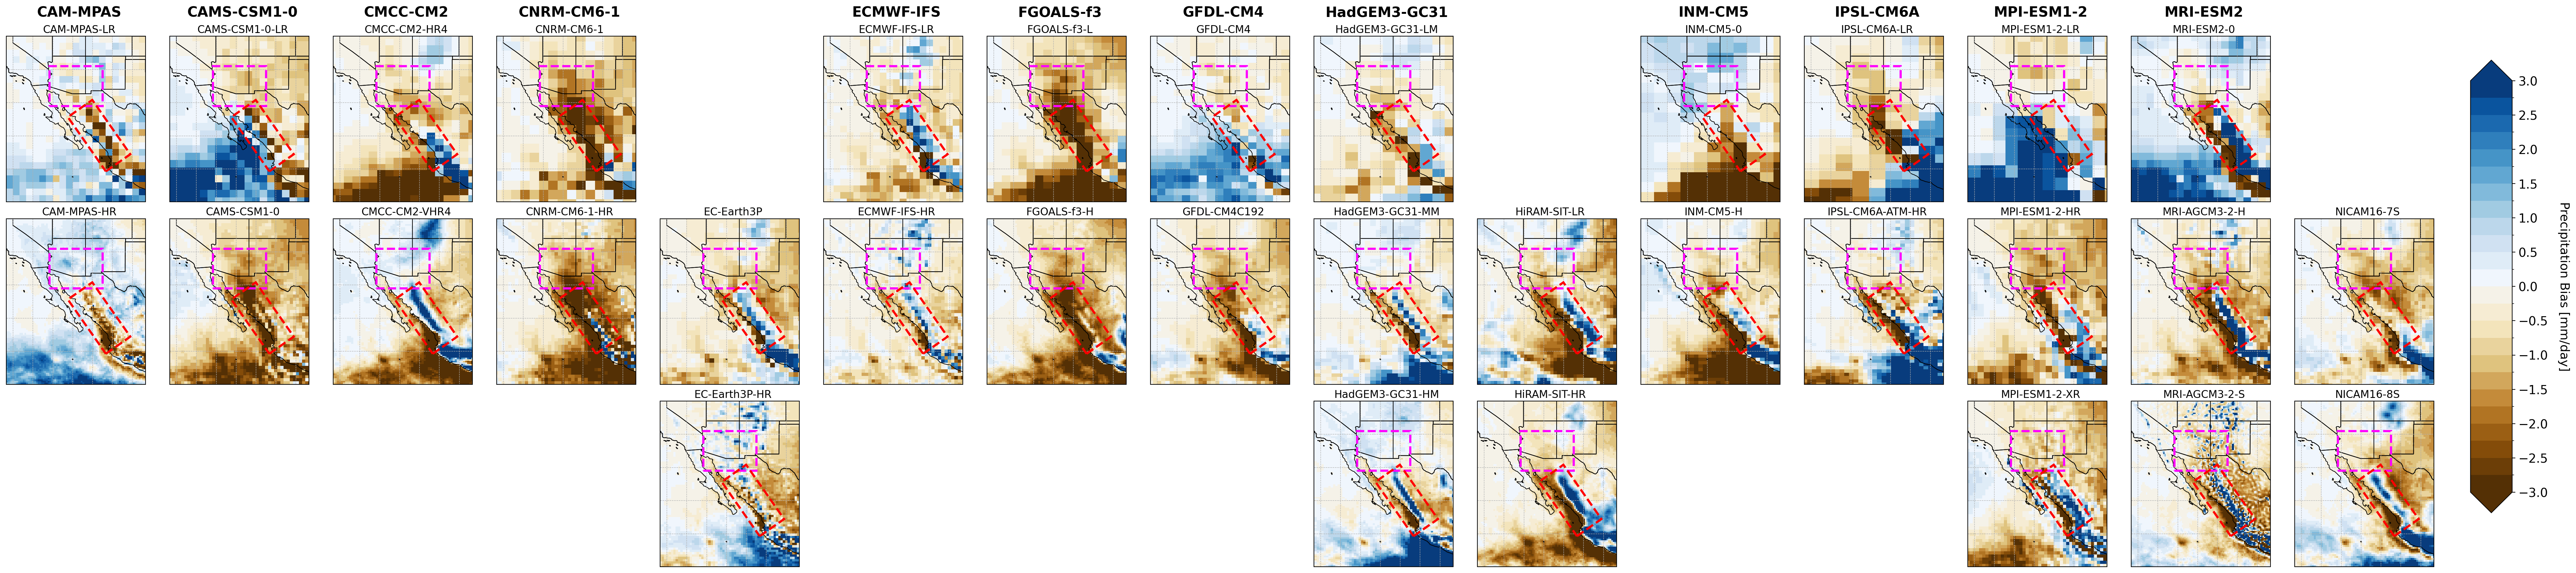

In [17]:
# choose which obs product to plot biases against
prod = 'imerg'

# settings
text_kw={'color':'k', 'weight':'bold', 'size':16, 'ha':'center', 'va':'bottom'}
tx=-110
ty=40.5
# bias colormap
dcmap,_,_,_=get_settings(field='precip', diff=True)
dvmin=-3
dvmax=3
dlevels=np.linspace(dvmin, dvmax, 25)
dnorm=mpl.colors.BoundaryNorm(dlevels, dcmap.N)
# map specs
trans=ccrs.PlateCarree()
proj=ccrs.PlateCarree()
map_bnds=[239,260,15,40]

families = list(lr_map.keys())
ncols = len(families)
max_hr = max(len(hr_map[f]) for f in families)
nrows = 1 + max_hr

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(2.6*ncols, 3*nrows),
    subplot_kw={'projection': proj},
    layout='constrained'
)


for col, family in enumerate(families):

    if len(lr_map[family]) > 0:

        model = lr_map[family][0]
        ax = axes[0, col]

        res = 'lr'

        lons = diff[prod][model].lon
        lats = diff[prod][model].lat
        bias = diff[prod][model]
        cf = ax.pcolormesh(lons, lats, bias, cmap=dcmap, norm=dnorm, transform=trans)

        ax.text(tx, ty, f"{model}", fontsize=12, ha='center')
        
    else:
        axes[0, col].set_visible(False)

    for i, model in enumerate(hr_map[family]):

        row = i + 1
        ax = axes[row, col]

        res = 'hr'

        lons = diff[prod][model].lon
        lats = diff[prod][model].lat
        bias = diff[prod][model]
        cf = ax.pcolormesh(lons, lats, bias, cmap=dcmap, norm=dnorm, transform=trans)

        ax.text(tx, ty, f"{model}", fontsize=12, ha='center')

    for row in range(1 + len(hr_map[family]), nrows):
        axes[row, col].set_visible(False)

    axes[0, col].text(tx, ty+2, family, **text_kw)

for ax in axes.flat:

    if not ax.get_visible():
        continue

    poly1 = patches.Polygon(
        coords_map['north'],
        closed=True,
        ec='magenta',
        fc='none',
        lw=2.5,
        ls='--',
        transform=ccrs.PlateCarree(),
        zorder=100
    )
    ax.add_patch(poly1)

    poly2 = patches.Polygon(
        coords_map['core'],
        closed=True,
        ec='red',
        fc='none',
        lw=2.5,
        ls='--',
        transform=ccrs.PlateCarree(),
        zorder=100
    )
    ax.add_patch(poly2)

    ax.coastlines(color='k', linewidth=.75)
    ax.add_feature(cfeature.STATES, linewidth=.75)
    ax.add_feature(cfeature.BORDERS, linewidth=.75)
    ax.set_extent(map_bnds, crs=trans)
    ax.gridlines(crs=trans, lw=.5, linestyle='--', draw_labels=False)
    
# colorbar
cax=fig.add_axes([1.01, 0.1, 0.017, 0.8])
cbar=fig.colorbar(cf, ticks=np.linspace(dvmin,dvmax,13), orientation='vertical', extend='both', cax=cax)
cbar.set_label('Precipitation Bias [mm/day]', labelpad=25, rotation=270, size=14, fontweight='normal', ha='center')
cbar.ax.tick_params(labelsize=14)
for tick in cbar.ax.yaxis.get_major_ticks():
    tick.label2.set_fontweight('normal')

## Scatter plot of change in bias magnitude

In [23]:
# store info about magnitude of bias in low res models
parent_lr_bias = { domain: {} for domain in domains }

for domain in domains:
    for parent, cfgs in lr_map.items():
        lr_cfg = cfgs[0]
        parent_lr_bias[domain][parent]  = nam_bias[domain]['imerg'][lr_cfg]

# sort low res models by size of bias
parent_models = {}
for domain in domains:
    parent_models[domain] = sorted(parent_lr_bias[domain], key=lambda m: parent_lr_bias[domain][m])

# determine plotting x positions based on sorted model bias magnitudes
xpos = { domain: {} for domain in domains }
for domain in domains:
    xpos[domain] = {m: i for i, m in enumerate(parent_models[domain])}

# map configuration names to parent model names
cfg_to_parent = {}
for parent, cfgs in lr_map.items():
    for cfg in cfgs:
        cfg_to_parent[cfg] = parent
for parent, cfgs in hr_map.items():
    for cfg in cfgs:
        cfg_to_parent[cfg] = parent

In [27]:
def plot_panel_horizontal(ax, source, domain, prod):

    line_kw = dict(color='0.7', lw=2, zorder=1)
    marker_kw = dict(marker='s', alpha=1, zorder=100, clip_on=False)
    
    models = parent_models[domain]
    yvals = np.arange(len(models))

    for y, parent in zip(yvals, models):

        # ---- LR ----
        lr_cfg = lr_map[parent][0]
        lr_val = source[domain][prod][lr_cfg]
        lr_size = (32500 / res_list[lr_cfg])
        ax.scatter(lr_val, y,
                   s=lr_size,
                   c='black', **marker_kw)

        # ---- HR ----
        for hr_cfg in hr_map[parent]:
            hr_val = source[domain][prod][hr_cfg]
            hr_size = (32500 / res_list[hr_cfg])
            ax.scatter(hr_val, y,
                       s=hr_size,
                       c='darkgoldenrod', **marker_kw)
            # connect LR → this HR with line
            ax.plot([lr_val, hr_val], [y, y], **line_kw)

    # ---- Axis formatting ----
    ax.axvline(0, color='k', ls='--', lw=1) # 0 bias line

    ax.invert_yaxis()
    ax.set_yticks(yvals)
    ax.set_yticklabels(models)
    
    ax.xaxis.tick_top()
    ax.tick_params(axis='x', bottom=False, labelbottom=False)
    ax.set(xlim=[-2.25,1.5])

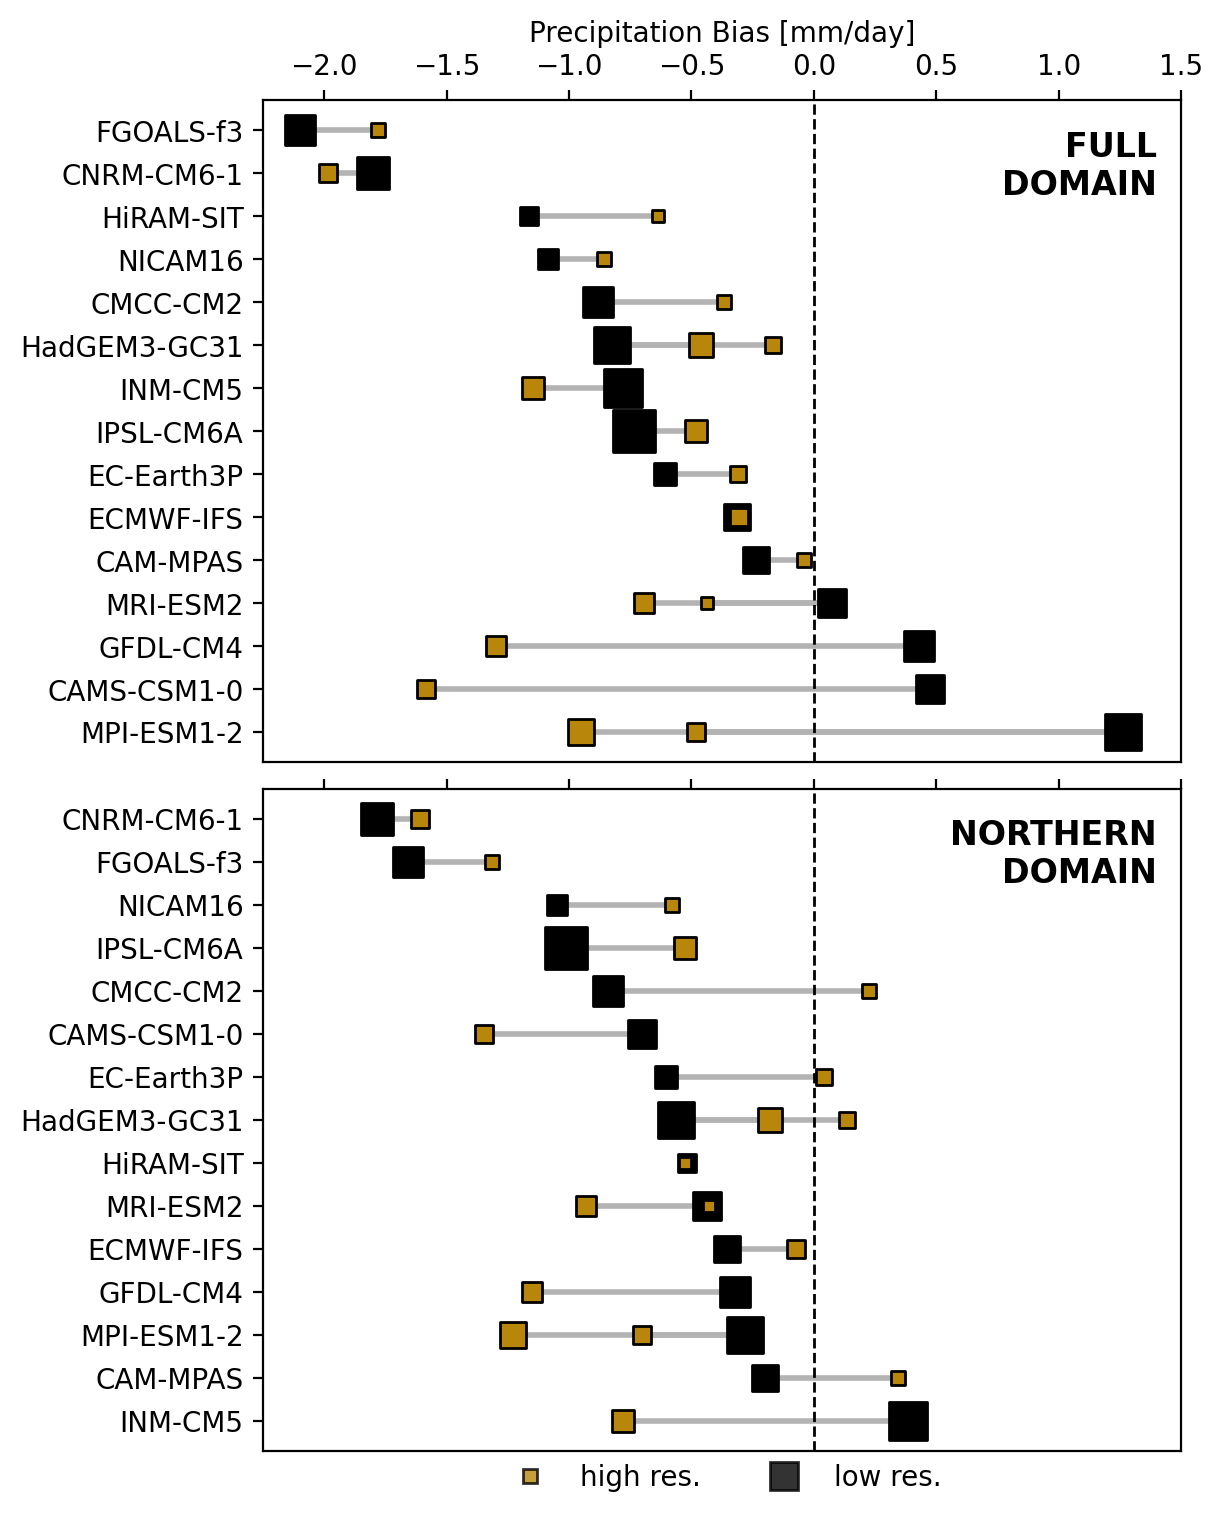

In [28]:
text_kw={'size':12, 'weight':'bold','color':'black', 'ha':'right', 'va':'top'}
legend_kw={'loc':'lower center', 'bbox_to_anchor':(.5,-0.1), 'ncol':2, 'fontsize':10, 'labelcolor':'k', 'frameon':False}
legend_handles = [ Line2D([0], [0], marker='s', color='w', alpha=.8,
                       markeredgecolor='k', markerfacecolor='darkgoldenrod',
                       markersize=5, label='high res.'),
                    Line2D([0], [0], marker='s', color='w', alpha=.8,
                       markeredgecolor='k', markerfacecolor='k',
                       markersize=10, label='low res.') ]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 7.5), sharex=False, constrained_layout=True)

ax1.text(1.4, 0, 'NORTHERN\nDOMAIN', **text_kw)
plot_panel_horizontal(ax1, nam_bias, 'north', 'imerg')
ax1.set_xlabel('Precipitation Bias [mm/day]')
ax1.xaxis.set_label_position('top')

ax3.text(1.4, 0, 'CORE\nDOMAIN', **text_kw)
plot_panel_horizontal(ax3, nam_bias, 'full', 'imerg')
ax3.tick_params(axis='x', bottom=False, labeltop=False)
ax3.legend(handles=legend_handles, **legend_kw)


In [ ]:
marker_cols=['darkred','peru']
label_text_kw=dict(fontsize=6, fontweight='bold', ha='right', va='bottom', alpha=0.8)
text_kw={'size':12, 'weight':'bold','color':'black', 'ha':'right', 'va':'top'}
legend_kw={'loc':'lower center', 'bbox_to_anchor':(.5,-0.1), 'ncol':2, 'fontsize':10, 'labelcolor':'k', 'frameon':False}
legend_handles = [ Line2D([0], [0], marker='s', color='w', alpha=.8,
                       markeredgecolor='k', markerfacecolor='darkgoldenrod',
                       markersize=5, label='high res.'),
                    Line2D([0], [0], marker='s', color='w', alpha=.8,
                       markeredgecolor='k', markerfacecolor='k',
                       markersize=10, label='low res.') ]

fig, (ax1, ax2, ax3, ax4) = plt.subplots(2, 2, figsize=(6, 7.5), sharex=False, constrained_layout=True)

ax1.text(1.4, 0, 'NORTHERN\nDOMAIN', **text_kw)
plot_panel_horizontal(ax1, nam_bias, 'north', 'imerg')
ax1.set_xlabel('Precipitation Bias [mm/day]')
ax1.xaxis.set_label_position('top')

ax3.text(1.4, 0, 'CORE\nDOMAIN', **text_kw)
plot_panel_horizontal(ax3, nam_bias, 'full', 'imerg')
ax3.tick_params(axis='x', bottom=False, labeltop=False)
ax3.legend(handles=legend_handles, **legend_kw)

for i,domain in enumerate(domains):
    mkr_col=marker_cols[i]
    x_lr, y_hr, parents = collect_lr_hr_pairs(nam_bias, domain=domain, prod='imerg')

    if domain=='north':
        ax=ax2
    else:
        ax=ax4
        
    ax.scatter(abs(x_lr), abs(y_hr),
               s=80, c=mkr_col, edgecolor='k',
               alpha=1, zorder=100)

    dx, dy = -0.025, 0.01
    for x, y, parent in zip(abs(x_lr), abs(y_hr), parents):
        ax.text(x+dx, y+dy, parent, color=mkr_col, **label_text_kw)
    
    # 1:1 reference line
    lims = [min(x_lr.min(), y_hr.min())-2, max(x_lr.max(), y_hr.max())+3]
    ax.plot(lims, lims, 'k--', lw=1)
    ax.set(xlabel='Low-resolution Bias [mm/day]',  xlim=[0,2.2],
           ylabel='High-resolution Bias [mm/day]', ylim=[0,2.2])
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)


## scatter plot

In [29]:
def collect_lr_hr_pairs(source, domain, prod):
    x_lr = []
    y_hr = []
    parents = []
    
    for parent in parent_models[domain]:
        # ---- LR ----
        lr_cfg = lr_map[parent][0]
        lr_val = source[domain][prod][lr_cfg].values.item()
        # ---- HR ----
        for hr_cfg in hr_map[parent]:
            hr_val = source[domain][prod][hr_cfg].values.item()
            # --- append to list ---
            x_lr.append(lr_val)
            y_hr.append(hr_val)
            parents.append(parent)

    return np.array(x_lr), np.array(y_hr), parents


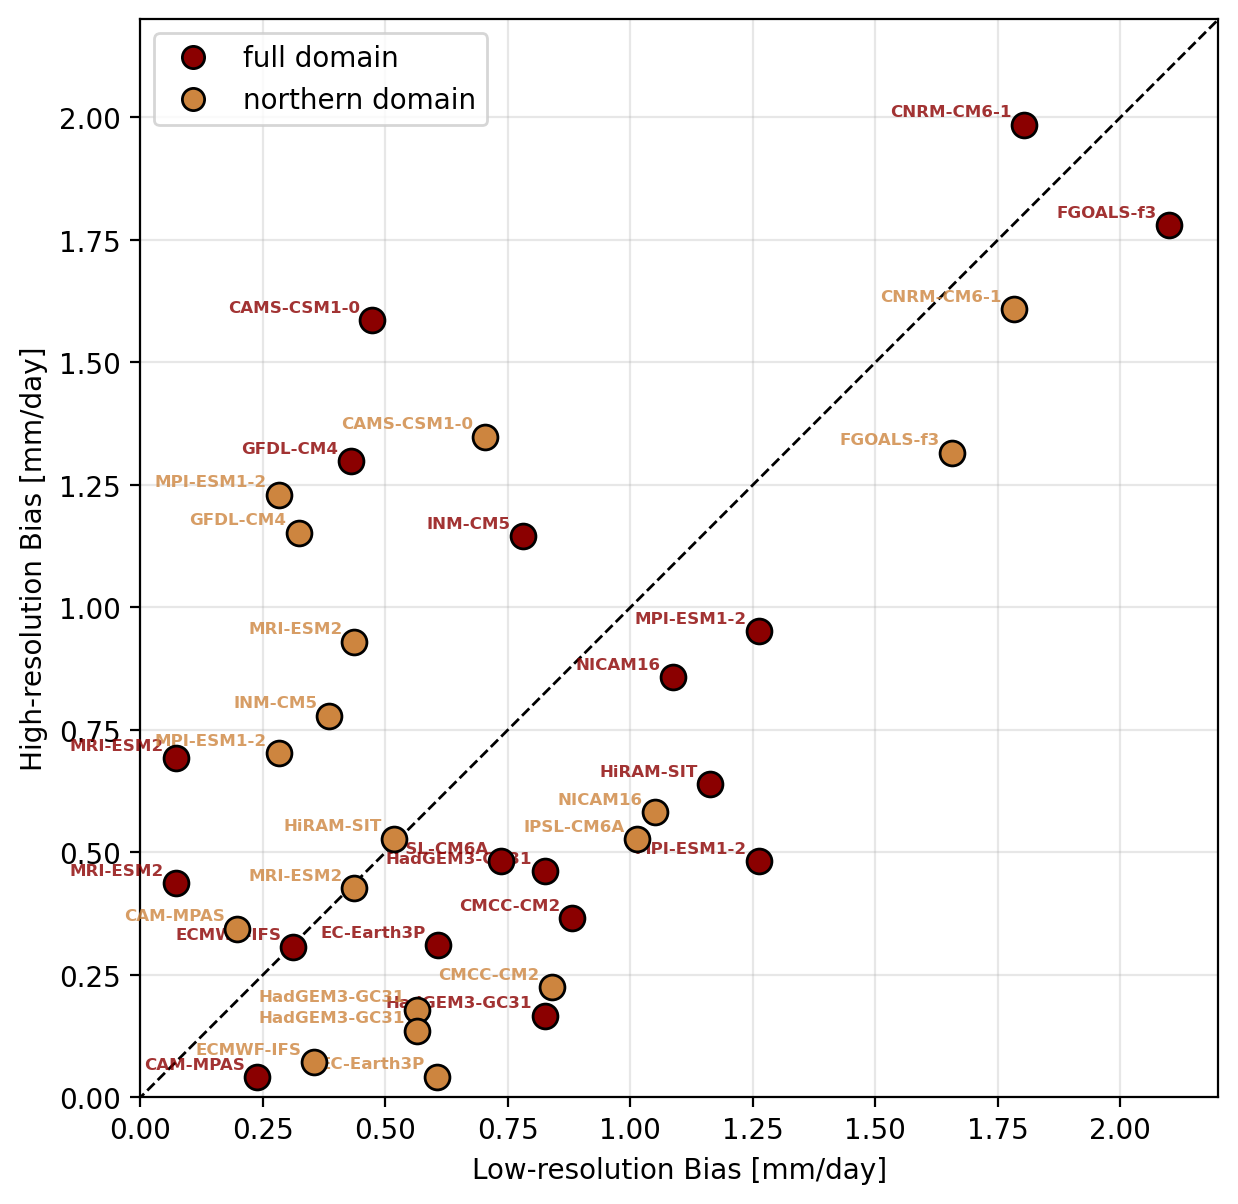

In [137]:
marker_cols=['darkred','peru']
label_text_kw=dict(fontsize=6, fontweight='bold', ha='right', va='bottom', alpha=0.8)
fig, ax = plt.subplots(figsize=(7,7))

for i,domain in enumerate(domains):
    mkr_col=marker_cols[i]
    x_lr, y_hr, parents = collect_lr_hr_pairs(nam_bias, domain=domain, prod='imerg')
    ax.scatter(abs(x_lr), abs(y_hr),
               s=80, c=mkr_col, edgecolor='k',
               alpha=1, zorder=100)

    dx, dy = -0.025, 0.01
    for x, y, parent in zip(abs(x_lr), abs(y_hr), parents):
        ax.text(x+dx, y+dy, parent, color=mkr_col, **label_text_kw)
    
# 1:1 reference line
lims = [min(x_lr.min(), y_hr.min())-2, max(x_lr.max(), y_hr.max())+3]
ax.plot(lims, lims, 'k--', lw=1)
ax.set(xlabel='Low-resolution Bias [mm/day]',  xlim=[0,2.2],
       ylabel='High-resolution Bias [mm/day]', ylim=[0,2.2])
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)

legend_kw={'loc':'upper left', 'bbox_to_anchor':(0,1), 'ncol':1, 'fontsize':10, 'labelcolor':'k', 'frameon':True}
legend_handles = [ Line2D([0], [0], marker='o', color='w', alpha=1,
                       mec='k', mfc='darkred',
                       markersize=8, label='full domain'),
                    Line2D([0], [0], marker='o', color='w', alpha=1,
                       mec='k', mfc='peru',
                       markersize=8, label='northern domain') ]
ax.legend(handles=legend_handles, **legend_kw)

In [97]:
def collect_resolution_delta_bias_mag(source, domain, prod):

    x_res = []
    y_dmag = []
    parents = []

    for parent in parent_models[domain]:

        lr_cfg = lr_map[parent][0]
        lr_bias = source[domain][prod][lr_cfg].values.item()
        lr_mag  = abs(lr_bias)
        lr_nlon = res_list[lr_cfg]

        for hr_cfg in hr_map[parent]:
            hr_bias = source[domain][prod][hr_cfg].values.item()
            hr_mag  = abs(hr_bias)
            hr_nlon = res_list[hr_cfg]

            # longitudinal resolution refinement
            x = np.log2(hr_nlon / lr_nlon)

            # change in bias magnitude (intuitive sign)
            y = hr_mag - lr_mag

            x_res.append(x)
            y_dmag.append(y)
            parents.append(parent)

    return np.array(x_res), np.array(y_dmag), parents


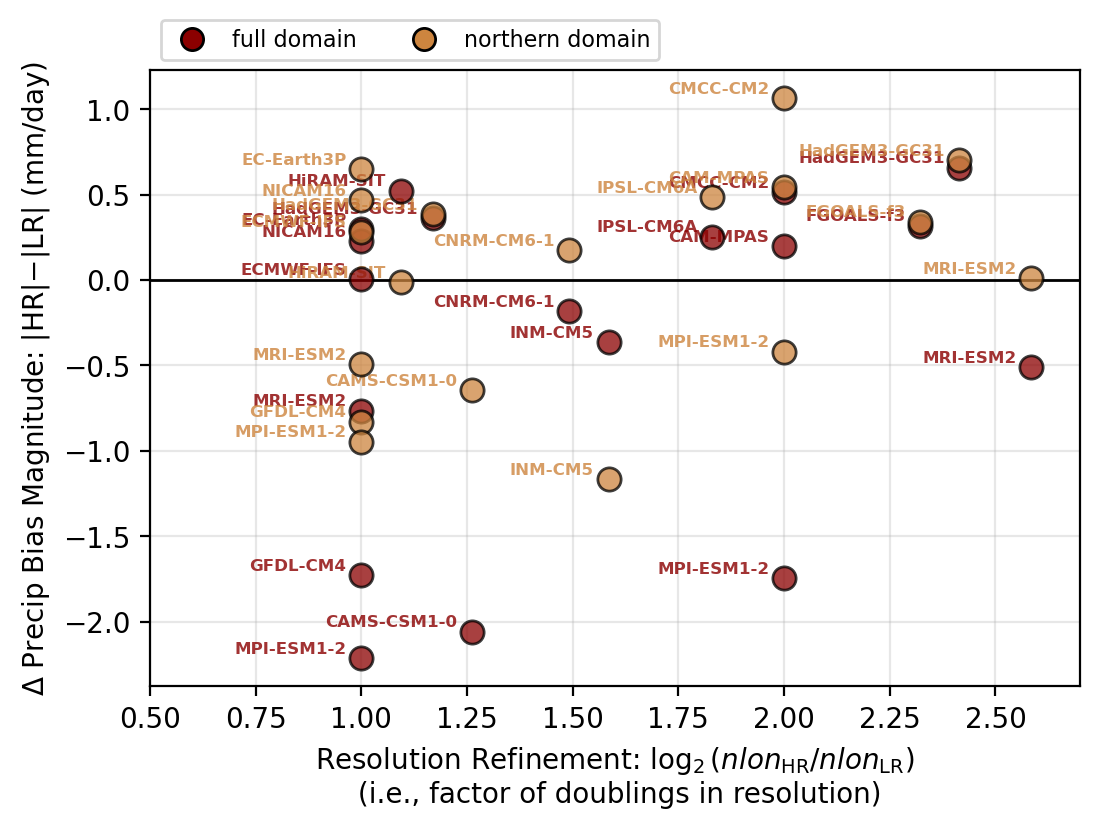

In [133]:
# Plot of change in horizontal resolution (as a factor in the number of doublings, where a factor of 1.0 = 2x increase in resolution (e.g., nlon=180 to nlon=360)
# compared to change in the magnitude of bias between HR and LR configurations of the same model family
# positive change in bias magnitude = bias worsened; negative change in bias magnitude = bias improved/reduced

marker_cols=['darkred','peru']
label_text_kw=dict(fontsize=6, fontweight='bold', ha='right', va='bottom', alpha=0.8)
fig, ax = plt.subplots(figsize=(6,4))

for i,domain in enumerate(domains):
    mkr_col=marker_cols[i]
    x_res, y_dbias, parents = collect_resolution_delta_bias(nam_bias, domain=domain, prod='imerg', use_log2=True)
    
    ax.scatter(x_res, y_dbias,
               s=70, c=mkr_col, edgecolor='k',
               alpha=0.75, zorder=100)

    dx, dy = -0.035, 0.01
    for x, y, parent in zip(x_res, y_dbias, parents):
        ax.text(x+dx, y+dy, parent, color=mkr_col, **label_text_kw)

# reference lines
ax.axhline(0, color='k', lw=1)   # no bias change
ax.axvline(0, color='k', lw=1)   # no resolution change

ax.set(xlabel=r'Resolution Refinement: $\log_2(nlon_{\mathrm{HR}} / nlon_{\mathrm{LR}})$'
               '\n (i.e., factor of doublings in resolution)',
       ylabel='$\Delta$ Precip Bias Magnitude: |HR|$−$|LR| (mm/day)',
       xlim=[0.5,2.7])

ax.grid(True, alpha=0.3)

legend_kw={'loc':'upper left', 'bbox_to_anchor':(0,1.1), 'ncol':2, 'fontsize':8, 'labelcolor':'k', 'frameon':True}
legend_handles = [ Line2D([0], [0], marker='o', color='w', alpha=1,
                       mec='k', mfc='darkred',
                       markersize=8, label='full domain'),
                    Line2D([0], [0], marker='o', color='w', alpha=1,
                       mec='k', mfc='peru',
                       markersize=8, label='northern domain') ]
ax.legend(handles=legend_handles, **legend_kw)

## map of all model biases

In [ ]:
#=== Plot historical biases all HRMIP models with historical simualtions ===
text_kw={'color':'k', 'weight':'bold', 'size':14, 'ha':'center', 'va':'bottom'}
tx=-110.5
ty=40.25
# bias colormap
prod='imerg'
dcmap,_,_,_=get_settings(field='precip', diff=True)
dvmin=-3
dvmax=3
dlevels=np.linspace(dvmin, dvmax, 13)
dnorm=mpl.colors.BoundaryNorm(dlevels, dcmap.N)
# map specs
trans=ccrs.PlateCarree()
proj=ccrs.PlateCarree()
map_bnds=[239,260,15,40]

# Flatten configs
lr_cfgs = [(model, cfg) for model in models for cfg in lr_map[model]]
hr_cfgs = [(model, cfg) for model in models for cfg in hr_map[model]]

n_lr = len(lr_cfgs)
n_hr = len(hr_cfgs)
ncols = max(n_lr, n_hr)

fig, ax = plt.subplots(nrows=2, ncols=ncols, figsize=(2.8*ncols, 7), layout='constrained', subplot_kw={'projection':proj})

# low res models
for i, (model, cfg) in enumerate(lr_cfgs):
    ds = allmodels[prod][cfg]
    cf = ax[0,i].pcolormesh(ds.lon, ds.lat, ds, cmap=dcmap, norm=dnorm, transform=trans)
    ax[0,i].text(tx, ty, cfg, **text_kw)

# high res models
for i, (model, cfg) in enumerate(hr_cfgs):
    ds = allmodels[prod][cfg]
    cf = ax[1,i].pcolormesh(ds.lon, ds.lat, ds, cmap=dcmap, norm=dnorm, transform=trans)
    ax[1,i].text(tx, ty, cfg, **text_kw)

# hide unused axes
for j in range(n_lr, ncols):
    ax[0, j].set_visible(False)
for j in range(n_hr, ncols):
    ax[1, j].set_visible(False)


for a in ax.flat:
    if not a.get_visible():
        continue
    box = patches.Rectangle((-114.5, 28.5), 7.5, 6.5,
                            lw=3, ls='--', ec='r', fc='none',
                            zorder=100, transform=trans)
    a.add_patch(box)
    a.coastlines(color='k', linewidth=.75)
    a.add_feature(cfeature.STATES, edgecolor='k', linewidth=.75)
    a.add_feature(cfeature.BORDERS, edgecolor='k', linewidth=.75)
    a.set_extent(map_bnds, crs=trans)
    gl=a.gridlines(crs=trans, lw=.5, colors='black',linestyle='--', draw_labels=False)
    """
    gl.bottom_labels=True; gl.left_labels=True; gl.top_labels=False; gl.right_labels=False
    gl.xformatter=LONGITUDE_FORMATTER
    gl.yformatter=LATITUDE_FORMATTER
    gl.xlabel_style={'color': 'black', 'weight': 'normal', 'size':10}
    gl.ylabel_style={'color': 'black', 'weight': 'normal', 'size':10}
    """
    
# colorbar
cax=fig.add_axes([1.01, 0.1, 0.02, 0.8])
cbar=fig.colorbar(cf, ticks=dlevels, orientation='vertical', extend='max', cax=cax)
cbar.set_label('Precipitation Bias [mm/day]', labelpad=25, rotation=270, size=14, fontweight='normal', ha='center')
cbar.ax.tick_params(labelsize=14)
for tick in cbar.ax.yaxis.get_major_ticks():
    tick.label2.set_fontweight('normal')

#plt.savefig(f'{dpath2}/figs/highresmip_jas_biases_low-res-models.png', transparent=False, bbox_inches='tight')